# TPCRP Evaluation

This notebook implements the TPCRP active learning strategy from Hacohen et al. (2022) 
and evaluates it across three frameworks:
1. **Fully supervised**: ResNet18 trained only on selected labeled examples
2. **Self-supervised embedding**: linear classifier on SimCLR features
3. **Semi-supervised**: FlexMatch trained on labeled + unlabeled data

We compare TPCRP against a random selection baseline across 5 active learning rounds 
with a budget of 10 examples per round.

**Prerequisites**: Run `notebook1_simclr_training.ipynb` first to generate embeddings.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import RandAugment
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Step 1: Setup and Load Data

Load saved embeddings from notebook 1 and prepare CIFAR-10 dataloaders for classifier training and evaluation.

In [5]:
# Load saved embeddings from notebook 1
embeddings = np.load('embeddings.npy')
labels = np.load('labels.npy')
print(f"Embeddings shape: {embeddings.shape}")
print(f"Labels shape: {labels.shape}")


# Load CIFAR-10 for classifier training and evaluation
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465], 
                         [0.2023, 0.1994, 0.2010])
])

def get_train_transform():
    return transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.4914, 0.4822, 0.4465],
                             [0.2023, 0.1994, 0.2010])
    ])

train_dataset = datasets.CIFAR10(root='./data', train=True,
                                  download=False, transform=get_train_transform())
test_dataset = datasets.CIFAR10(root='./data', train=False, 
                                 download=False, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=512, 
                         shuffle=False, num_workers=4)
print("Data ready!")

Embeddings shape: (50000, 512)
Labels shape: (50000,)
Data ready!


## Step 2: Typicality Scoring
Typicality is computed **per cluster** (not globally over the pool) using K=min(20, cluster_size−1) nearest neighbours within each cluster, as per Equation 4 of the paper. Higher typicality = point lies in a denser region of its cluster = more representative of that cluster.

In [7]:
def compute_typicality(cluster_embeddings):
    """
    Intra-cluster typicality: KNN computed within the cluster only.
    Adaptive K = min(20, n-1), matching Appendix F.1.
    """
    n = len(cluster_embeddings)
    k = min(20, n-1)
    if k < 1:
        return np.ones(n)

    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(cluster_embeddings)  # k+1 because point includes itself
    distances, _ = nbrs.kneighbors(cluster_embeddings)

    # Exclude the first column (distance to itself = 0)
    avg_distances = distances[:, 1:].mean(axis=1)

    # Typicality = inverse of average distance
    typicality = 1.0 / (avg_distances + 1e-8)  # small epsilon to avoid division by zero

    return typicality

## Step 3: TPC_RP Selection
Greedily select B points one at a time from K=min(|L|+B, 500) clusters, using KMeans for K≤50 and MiniBatchKMeans otherwise. Each step picks the cluster with fewest labeled points, skipping clusters with fewer than 5 points, then selects the unlabeled point with the highest intra-cluster typicality.

In [8]:
def tpcrp_select(embeddings, budget, labeled_indices=None, max_clusters=500):
    """
    TPCRP: K-Means clustering + select most typical point from each cluster.
    Typicality computed intra-cluster per Appendix F.1.
    """
    n_clusters = min(len(labeled_indices) + budget if labeled_indices is not None
                     else budget, max_clusters)

    if n_clusters <= 50:
        kmeans = KMeans(n_clusters=n_clusters, n_init=10)
    else:
        kmeans = MiniBatchKMeans(n_clusters=n_clusters, n_init=10, batch_size=5000)

    cluster_assignments = kmeans.fit_predict(embeddings)

    if labeled_indices is not None and len(labeled_indices) > 0:
        labeled_clusters = set(cluster_assignments[labeled_indices])
        uncovered = [c for c in range(n_clusters) if c not in labeled_clusters]
    else:
        uncovered = list(range(n_clusters))

    # Drop clusters smaller than 5 samples per Appendix F.1
    cluster_sizes = {c: np.sum(cluster_assignments == c) for c in uncovered}
    uncovered = [c for c in uncovered if cluster_sizes[c] > 5]

    # Pick B largest uncovered clusters
    largest_clusters = sorted(uncovered, key=lambda c: cluster_sizes[c], reverse=True)[:budget]

    selected_indices = []
    for cluster_id in largest_clusters:
        cluster_mask = np.where(cluster_assignments == cluster_id)[0]
        cluster_typicality = compute_typicality(embeddings[cluster_mask])  # intra-cluster
        best = cluster_mask[np.argmax(cluster_typicality)]
        selected_indices.append(best)

    return np.array(selected_indices)

## Step 4: Classifier Training

Train ResNet18 from scratch on the selected labeled examples only. Weights are reinitialised each round as per Appendix F.2.1.

In [9]:
def train_classifier(train_indices, train_dataset, test_loader, device, epochs=100):
    """
    Train ResNet18 on the labeled examples selected by TPCRP.
    Fully supervised framework as per paper Appendix F.2.1
    """
    # Subset of labeled examples only
    labeled_dataset = Subset(train_dataset, train_indices)
    labeled_loader = DataLoader(labeled_dataset, batch_size=32, 
                                shuffle=True, num_workers=0)
    
    classifier = models.resnet18(weights=None)
    classifier.fc = nn.Linear(512, 10)  # 10 classes for CIFAR-10
    classifier = classifier.to(device)
    
    optimizer = optim.SGD(classifier.parameters(), lr=0.025, 
                          momentum=0.9, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    # Training loop
    classifier.train()
    for epoch in range(epochs):
        for imgs, targets in labeled_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = classifier(imgs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
        scheduler.step()
    
    # Evaluate on test set
    classifier.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            outputs = classifier(imgs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total += targets.size(0)
    
    accuracy = 100. * correct / total
    return accuracy

## Step 5: Active Learning Loop

Run 5 rounds of active learning with budget B=10 per round. Compare TPCRP against random selection baseline.

In [10]:
N_REPS = 10
all_tpcrp_accuracies = []

def run_active_learning(embeddings, train_data, test_loader, device, budget=10, n_rounds=5):
    """
    Active learning loop for TPCRP.
    Budget=10 (1 per class), 5 rounds as per paper Fig 4a top.
    """
    labeled_indices = []
    accuracies = []
    cumulative_budgets = []
    
    for round_idx in range(n_rounds):
        print(f"\nRound {round_idx+1}/{n_rounds}")
        
        # Select new examples using TPCRP
        new_indices = tpcrp_select(
            embeddings, budget, 
            labeled_indices=np.array(labeled_indices) if labeled_indices else None
        )
        
        labeled_indices.extend(new_indices.tolist())
        cumulative_budget = len(labeled_indices)
        
        print(f"Total labeled examples: {cumulative_budget}")
        
        # Train classifier on all labeled examples so far
        accuracy = train_classifier(labeled_indices, train_dataset, 
                                   test_loader, device)
        accuracies.append(accuracy)
        cumulative_budgets.append(cumulative_budget)
        
        print(f"Accuracy: {accuracy:.2f}%")
    
    return cumulative_budgets, accuracies


# Run TPCRP
print("Running TPCRP...")

for rep in range(N_REPS):
    print(f"\n--- TPCRP Repetition {rep+1}/{N_REPS} ---")
    _, rep_accuracies = run_active_learning(embeddings, train_dataset, test_loader, device)
    all_tpcrp_accuracies.append(rep_accuracies)

all_tpcrp_accuracies = np.array(all_tpcrp_accuracies)  # shape [10, 5]
np.save('tpcrp_accuracies.npy', all_tpcrp_accuracies)
print(f"\nMean TPCRP accuracy per round: {all_tpcrp_accuracies.mean(axis=0).round(2)}")
print(f"\nSTD TPCRP accuracy per round: {all_tpcrp_accuracies.std(axis=0).round(2)}")

Running TPCRP...

--- TPCRP Repetition 1/10 ---

Round 1/5
Total labeled examples: 10
Accuracy: 12.28%

Round 2/5
Total labeled examples: 20
Accuracy: 17.50%

Round 3/5
Total labeled examples: 30
Accuracy: 20.69%

Round 4/5
Total labeled examples: 40
Accuracy: 22.77%

Round 5/5
Total labeled examples: 50
Accuracy: 24.36%

--- TPCRP Repetition 2/10 ---

Round 1/5
Total labeled examples: 10
Accuracy: 12.66%

Round 2/5
Total labeled examples: 20
Accuracy: 18.46%

Round 3/5
Total labeled examples: 30
Accuracy: 21.04%

Round 4/5
Total labeled examples: 40
Accuracy: 20.64%

Round 5/5
Total labeled examples: 50
Accuracy: 25.84%

--- TPCRP Repetition 3/10 ---

Round 1/5
Total labeled examples: 10
Accuracy: 13.30%

Round 2/5
Total labeled examples: 20
Accuracy: 18.96%

Round 3/5
Total labeled examples: 30
Accuracy: 22.52%

Round 4/5
Total labeled examples: 40
Accuracy: 23.48%

Round 5/5
Total labeled examples: 50
Accuracy: 25.63%

--- TPCRP Repetition 4/10 ---

Round 1/5
Total labeled examples:

## Step 7: Random Baseline Over 10 Repetitions

Random selection samples B=10 examples per round with no use of embeddings or typicality the primary baseline from Fig. 4a.

In [13]:
def run_random_baseline(train_dataset, test_loader, device,
                        n_pool=50000, budget=10, n_rounds=5):
    labeled_indices = []
    accuracies = []
    cumulative_budgets = []

    for round_idx in range(n_rounds):
        
        print(f"\nRound {round_idx+1}/{n_rounds}")
        
        remaining = list(set(range(n_pool)) - set(labeled_indices))
        new_indices = np.random.choice(remaining, budget, replace=False).tolist()
        labeled_indices.extend(new_indices)
        accuracy = train_classifier(labeled_indices, train_dataset, test_loader, device)
        accuracies.append(accuracy)
        cumulative_budgets.append(len(labeled_indices))
        
        print(f"Total labeled: {len(labeled_indices)} | Accuracy: {accuracy:.2f}%")

    return cumulative_budgets, accuracies

all_random_accuracies = []

for rep in range(N_REPS):
    print(f"\n--- Random Repetition {rep+1}/{N_REPS} ---")
    _, rep_accuracies = run_random_baseline(train_dataset, test_loader, device)
    all_random_accuracies.append(rep_accuracies)

all_random_accuracies = np.array(all_random_accuracies)  # shape [10, 5]
np.save('random_accuracies.npy', all_random_accuracies)
print(f"\nMean Random accuracy per round: {all_random_accuracies.mean(axis=0).round(2)}")
print(f"\nSTD TPCRP accuracy per round: {all_tpcrp_accuracies.std(axis=0).round(2)}")


--- Random Repetition 1/10 ---

Round 1/5
Total labeled: 10 | Accuracy: 15.32%

Round 2/5
Total labeled: 20 | Accuracy: 14.08%

Round 3/5
Total labeled: 30 | Accuracy: 18.84%

Round 4/5
Total labeled: 40 | Accuracy: 16.49%

Round 5/5
Total labeled: 50 | Accuracy: 20.66%

--- Random Repetition 2/10 ---

Round 1/5
Total labeled: 10 | Accuracy: 11.34%

Round 2/5
Total labeled: 20 | Accuracy: 14.81%

Round 3/5
Total labeled: 30 | Accuracy: 19.55%

Round 4/5
Total labeled: 40 | Accuracy: 19.50%

Round 5/5
Total labeled: 50 | Accuracy: 20.28%

--- Random Repetition 3/10 ---

Round 1/5
Total labeled: 10 | Accuracy: 11.81%

Round 2/5
Total labeled: 20 | Accuracy: 15.19%

Round 3/5
Total labeled: 30 | Accuracy: 17.64%

Round 4/5
Total labeled: 40 | Accuracy: 17.35%

Round 5/5
Total labeled: 50 | Accuracy: 20.53%

--- Random Repetition 4/10 ---

Round 1/5
Total labeled: 10 | Accuracy: 13.90%

Round 2/5
Total labeled: 20 | Accuracy: 17.47%

Round 3/5
Total labeled: 30 | Accuracy: 18.66%

Round 4

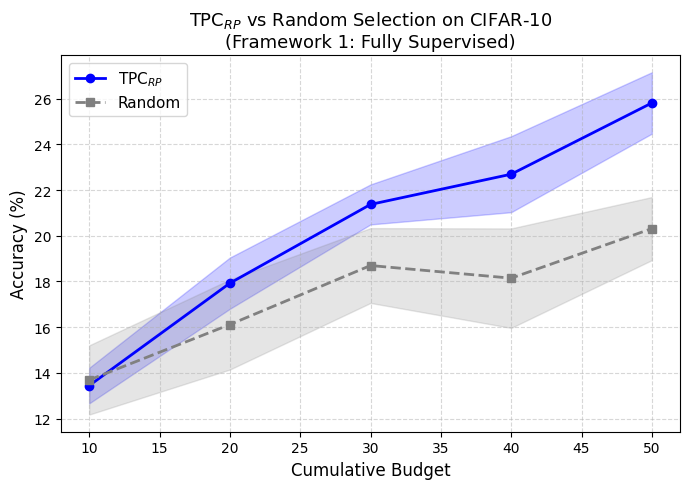

In [17]:
budgets = [10, 20, 30, 40, 50]

tpcrp_mean = all_tpcrp_accuracies.mean(axis=0)
tpcrp_std  = all_tpcrp_accuracies.std(axis=0)
rand_mean  = all_random_accuracies.mean(axis=0)
rand_std   = all_random_accuracies.std(axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(budgets, tpcrp_mean, marker='o', color='blue', linewidth=2, label='TPC$_{RP}$')
ax.fill_between(budgets, tpcrp_mean - tpcrp_std, tpcrp_mean + tpcrp_std, alpha=0.2, color='blue')

ax.plot(budgets, rand_mean, marker='s', color='gray', linewidth=2, linestyle='--', label='Random')
ax.fill_between(budgets, rand_mean - rand_std, rand_mean + rand_std, alpha=0.2, color='gray')

ax.set_xlabel('Cumulative Budget', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('TPC$_{RP}$ vs Random Selection on CIFAR-10\n(Framework 1: Fully Supervised)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_framework1.png', dpi=150)
plt.show()

## Step 8: Framework 2, Linear Probe on Frozen SimCLR Embeddings

Instead of training ResNet-18 from scratch, we freeze the SimCLR encoder and train a single linear layer (512→10) on the L2-normalised embeddings. Following Appendix F.2.2, we use SGD with lr=2.5, momentum=0.9, Nesterov, 100 epochs, and a cosine annealing scheduler.

In [11]:
# Reload SimCLR to extract test embeddings
class SimCLR(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        resnet = models.resnet18(weights=None)
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])
        self.projector = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, projection_dim)
        )
    def forward(self, x):
        h = self.encoder(x).squeeze()
        z = self.projector(h)
        return h, z

simclr = SimCLR().to(device)
simclr.load_state_dict(torch.load('simclr_model.pth', map_location=device))
simclr.eval()

test_loader_seq = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=4)
test_embs, test_lbls = [], []
with torch.no_grad():
    for imgs, targets in tqdm(test_loader_seq, desc="Extracting test embeddings"):
        h, _ = simclr(imgs.to(device))
        h = nn.functional.normalize(h, dim=1)
        test_embs.append(h.cpu().numpy())
        test_lbls.append(targets.numpy())
test_embeddings = np.concatenate(test_embs)   # [10000, 512]
test_labels_arr = np.concatenate(test_lbls)   # [10000]
print(f"Test embeddings: {test_embeddings.shape}")


def train_linear_probe(labeled_indices, train_embeddings, train_labels,
                       test_embeddings, test_labels_arr, epochs=200):
    """
    SGD linear probe on frozen SimCLR embeddings.
    lr=2.5 (0.025 x100), epochs=200 (100 x2), cosine scheduler.
    Per Appendix F.2.2 of Hacohen et al. (2022).
    """
    X = train_embeddings[labeled_indices]
    y = train_labels[labeled_indices]
    n = len(X)
    batch_size = 32

    probe = nn.Linear(512, 10).to(device)
    optimizer = optim.SGD(probe.parameters(), lr=2.5,
                          momentum=0.9, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    probe.train()
    for epoch in range(epochs):
        perm = np.random.permutation(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            xb = torch.tensor(X[idx], dtype=torch.float32).to(device)
            yb = torch.tensor(y[idx], dtype=torch.long).to(device)
            optimizer.zero_grad()
            criterion(probe(xb), yb).backward()
            optimizer.step()
        scheduler.step()

    probe.eval()
    X_test = torch.tensor(test_embeddings, dtype=torch.float32).to(device)
    y_test = torch.tensor(test_labels_arr, dtype=torch.long).to(device)
    with torch.no_grad():
        preds = probe(X_test).argmax(dim=1)
    return 100. * (preds == y_test).float().mean().item()


def run_linear_probe_al(embeddings, train_labels, test_embeddings, test_labels_arr,
                        budget=10, n_rounds=5, use_tpcrp=True):
    labeled_indices = []
    accuracies = []
    cumulative_budgets = []

    for round_idx in range(n_rounds):
        if use_tpcrp:
            new_indices = tpcrp_select(
                embeddings, budget,
                labeled_indices=np.array(labeled_indices) if labeled_indices else None
            )
        else:
            remaining = list(set(range(len(embeddings))) - set(labeled_indices))
            new_indices = np.random.choice(remaining, budget, replace=False)

        labeled_indices.extend(new_indices.tolist())
        acc = train_linear_probe(labeled_indices, embeddings, train_labels,
                                 test_embeddings, test_labels_arr)
        accuracies.append(acc)
        cumulative_budgets.append(len(labeled_indices))

    return cumulative_budgets, accuracies


all_tpcrp_lp, all_random_lp = [], []

for rep in range(N_REPS):
    print(f"\nLinear Probe Rep {rep+1}/{N_REPS}")
    _, t_accs = run_linear_probe_al(embeddings, labels,
                                    test_embeddings, test_labels_arr, use_tpcrp=True)
    _, r_accs = run_linear_probe_al(embeddings, labels,
                                    test_embeddings, test_labels_arr, use_tpcrp=False)
    all_tpcrp_lp.append(t_accs)
    all_random_lp.append(r_accs)
    print(f"  TPCRP LP: {[f'{x:.2f}' for x in t_accs]} | Random LP: {[f'{x:.2f}' for x in r_accs]}")

all_tpcrp_lp  = np.array(all_tpcrp_lp)
all_random_lp = np.array(all_random_lp)
np.save('tpcrp_lp_accuracies.npy',  all_tpcrp_lp)
np.save('random_lp_accuracies.npy', all_random_lp)

tpcrp_lp_mean = all_tpcrp_lp.mean(axis=0).round(2)
tpcrp_lp_std  = all_tpcrp_lp.std(axis=0).round(2)
rand_lp_mean  = all_random_lp.mean(axis=0).round(2)
rand_lp_std   = all_random_lp.std(axis=0).round(2)
print(f"\nTPCRP LP mean: {tpcrp_lp_mean} | std: {tpcrp_lp_std}")
print(f"Random LP mean: {rand_lp_mean} | std: {rand_lp_std}")

Extracting test embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 79.32it/s]


Test embeddings: (10000, 512)

Linear Probe Rep 1/10
  TPCRP LP: ['44.65', '58.21', '65.03', '69.55', '70.55'] | Random LP: ['42.16', '50.67', '48.13', '57.83', '62.49']

Linear Probe Rep 2/10
  TPCRP LP: ['44.70', '58.73', '66.75', '69.20', '70.91'] | Random LP: ['39.00', '47.30', '54.08', '56.25', '59.02']

Linear Probe Rep 3/10
  TPCRP LP: ['44.58', '57.83', '64.89', '64.87', '67.75'] | Random LP: ['43.36', '45.97', '48.96', '52.41', '58.95']

Linear Probe Rep 4/10
  TPCRP LP: ['45.59', '61.10', '67.11', '69.55', '70.39'] | Random LP: ['44.08', '45.24', '48.45', '52.78', '53.51']

Linear Probe Rep 5/10
  TPCRP LP: ['44.64', '58.88', '65.37', '69.68', '70.53'] | Random LP: ['38.51', '45.09', '52.54', '54.63', '62.30']

Linear Probe Rep 6/10
  TPCRP LP: ['44.67', '58.78', '66.59', '69.05', '71.16'] | Random LP: ['45.05', '54.70', '58.38', '58.79', '57.70']

Linear Probe Rep 7/10
  TPCRP LP: ['44.68', '58.81', '64.05', '66.85', '69.01'] | Random LP: ['37.41', '47.81', '50.30', '53.42',

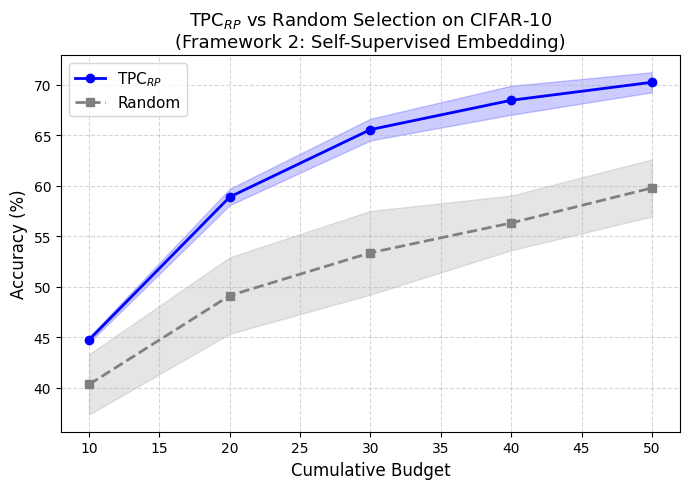

In [16]:
tpcrp_lp_mean = all_tpcrp_lp.mean(axis=0)
tpcrp_lp_std  = all_tpcrp_lp.std(axis=0)
rand_lp_mean  = all_random_lp.mean(axis=0)
rand_lp_std   = all_random_lp.std(axis=0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(budgets, tpcrp_lp_mean, marker='o', color='blue', linewidth=2, label='TPC$_{RP}$')
ax.fill_between(budgets, tpcrp_lp_mean - tpcrp_lp_std, tpcrp_lp_mean + tpcrp_lp_std, alpha=0.2, color='blue')

ax.plot(budgets, rand_lp_mean, marker='s', color='grey', linewidth=2, linestyle='--', label='Random')
ax.fill_between(budgets, rand_lp_mean - rand_lp_std, rand_lp_mean + rand_lp_std, alpha=0.2, color='grey')

ax.set_xlabel('Cumulative Budget', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('TPC$_{RP}$ vs Random Selection on CIFAR-10\n(Framework 2: Self-Supervised Embedding)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot_framework2.png', dpi=150)
plt.show()

## Step 9: Framework 3 Semi-Supervised Learning with FlexMatch

We use FlexMatch (Zhang et al., 2021) as the semi-supervised classifier, trained on the
labeled examples selected by TPCRP plus the full unlabeled pool. Following Appendix F.2.3,
we train WideResNet-28 for 50k iterations and repeat 3 times for CIFAR-10.

In [19]:
class WideResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride, drop_rate=0.0, leaky_slope=0.1):
        super().__init__()
        self.bn1   = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.drop_rate   = drop_rate
        self.leaky_slope = leaky_slope
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False)

    def forward(self, x):
        out = F.leaky_relu(self.bn1(x), self.leaky_slope)
        out = self.conv1(out)
        out = F.leaky_relu(self.bn2(out), self.leaky_slope)
        if self.drop_rate > 0:
            out = F.dropout(out, p=self.drop_rate, training=self.training)
        out = self.conv2(out)
        return out + self.shortcut(x)

class WideResNet28(nn.Module):
    def __init__(self, widen_factor=2, num_classes=10, drop_rate=0.0, leaky_slope=0.1):
        super().__init__()
        widths = [16, 16 * widen_factor, 32 * widen_factor, 64 * widen_factor]

        self.conv1  = nn.Conv2d(3, widths[0], 3, padding=1, bias=False)
        self.layer1 = self._make_layer(widths[0], widths[1], stride=1, n=4, drop_rate=drop_rate, leaky_slope=leaky_slope)
        self.layer2 = self._make_layer(widths[1], widths[2], stride=2, n=4, drop_rate=drop_rate, leaky_slope=leaky_slope)
        self.layer3 = self._make_layer(widths[2], widths[3], stride=2, n=4, drop_rate=drop_rate, leaky_slope=leaky_slope)
        self.bn     = nn.BatchNorm2d(widths[3])
        self.fc     = nn.Linear(widths[3], num_classes)
        self.leaky_slope = leaky_slope

    def _make_layer(self, in_c, out_c, stride, n, drop_rate, leaky_slope):
        layers = [WideResNetBlock(in_c, out_c, stride, drop_rate, leaky_slope)]
        for _ in range(1, n):
            layers.append(WideResNetBlock(out_c, out_c, 1, drop_rate, leaky_slope))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.leaky_relu(self.bn(out), self.leaky_slope)
        out = F.adaptive_avg_pool2d(out, 1).view(out.size(0), -1)
        return self.fc(out)

print("WideResNet-28 defined.")

WideResNet-28 defined.


## Step 10: FlexMatch Training Loop

FlexMatch extends FixMatch with per-class adaptive thresholds. For each unlabeled image,
weak and strong augmentations are generated. If the model's confidence on the weak view
exceeds the per-class threshold, the prediction is used as a pseudo-label for the strong
view. The threshold for each class adapts based on how many samples have been
pseudo-labeled for that class, following a curriculum schedule. I'll be running 50000 iterations per repetition due to compute constraints.

In [23]:
def get_weak_transform():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010])
    ])

def get_strong_transform():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        RandAugment(num_ops=2, magnitude=10),
        transforms.ToTensor(),
        transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010])
    ])

class TwoTransformDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, weak_transform, strong_transform):
        self.dataset          = dataset
        self.weak_transform   = weak_transform
        self.strong_transform = strong_transform

    def __len__(self): return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset.data[idx], self.dataset.targets[idx]
        img = transforms.ToPILImage()(img)
        return self.weak_transform(img), self.strong_transform(img), label

weak_transform   = get_weak_transform()
strong_transform = get_strong_transform()

labeled_dataset_aug = datasets.CIFAR10(root='./data', train=True, download=False, transform=weak_transform)

unlabeled_full = TwoTransformDataset(
    datasets.CIFAR10(root='./data', train=True, download=False),
    weak_transform, strong_transform
)
unlabeled_loader = DataLoader(unlabeled_full, batch_size=64 * 7,
                              shuffle=True, num_workers=8, drop_last=True)

def train_flexmatch(labeled_indices, test_loader, device,
                    n_iterations=50000, threshold=0.95, num_classes=10,
                    lr=0.03, momentum=0.9, weight_decay=0.0005,
                    batch_size=64, leaky_slope=0.1):

    # Labeled loader
    labeled_loader = DataLoader(Subset(labeled_dataset_aug, labeled_indices),
                                batch_size=min(batch_size, len(labeled_indices)),
                                shuffle=True, num_workers=0, drop_last=False)

    model     = WideResNet28(widen_factor=2, num_classes=num_classes,
                              drop_rate=0.0, leaky_slope=leaky_slope).to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum,
                          weight_decay=weight_decay, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_iterations)
    criterion = nn.CrossEntropyLoss()

    # Per-class pseudo-label counts for FlexMatch threshold
    class_counts = torch.zeros(num_classes).to(device)

    labeled_iter   = iter(labeled_loader)
    unlabeled_iter = iter(unlabeled_loader)

    model.train()
    for iteration in tqdm(range(n_iterations), desc="FlexMatch Training"):
        # Labeled batch
        try:
            imgs_l, targets_l = next(labeled_iter)
        except StopIteration:
            labeled_iter = iter(labeled_loader)
            imgs_l, targets_l = next(labeled_iter)

        # Unlabeled batch
        try:
            imgs_weak, imgs_strong, _ = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            imgs_weak, imgs_strong, _ = next(unlabeled_iter)

        imgs_l      = imgs_l.to(device)
        targets_l   = targets_l.to(device)
        imgs_weak   = imgs_weak.to(device)
        imgs_strong = imgs_strong.to(device)

        # Labeled loss
        loss_labeled = criterion(model(imgs_l), targets_l)

        # Pseudo-labels from weak augmentation
        with torch.no_grad():
            probs = torch.softmax(model(imgs_weak), dim=1)
            scores, pseudo_labels = probs.max(dim=1)

            # FlexMatch adaptive threshold per class
            sigma      = class_counts / (class_counts.max() + 1e-8)
            thresholds = threshold * sigma[pseudo_labels]
            mask       = scores >= thresholds

            # Update class counts
            for c in pseudo_labels[mask]:
                class_counts[c] += 1

        # Unlabeled loss on strong augmentation
        if mask.sum() > 0:
            loss_unlabeled = criterion(model(imgs_strong)[mask], pseudo_labels[mask])
        else:
            loss_unlabeled = torch.tensor(0.0).to(device)

        loss = loss_labeled + loss_unlabeled
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        if (iteration + 1) % 25000 == 0:
            print(f"  Iteration {iteration+1}/{n_iterations} | Loss: {loss.item():.4f}")

    # Evaluate
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            _, pred = model(imgs).max(1)
            correct += pred.eq(targets).sum().item()
            total   += targets.size(0)
    return 100. * correct / total


# 3 repetitions as per paper Appendix F.2.3
N_REPS_SSL = 3
all_flexmatch_tpcrp   = []
all_flexmatch_random  = []

for rep in range(N_REPS_SSL):
    print(f"\nFlexMatch Rep {rep+1}/{N_REPS_SSL}")

    # Use TPCRP selection (budget=10, first round only as paper shows final accuracy)
    tpcrp_idx = tpcrp_select(embeddings, 10,
                              labeled_indices=None).tolist()
    t_acc = train_flexmatch(tpcrp_idx, test_loader, device)
    all_flexmatch_tpcrp.append(t_acc)
    print(f"  TPCRP FlexMatch: {t_acc:.2f}%")

    # Random selection
    r_idx = np.random.choice(len(embeddings), 10, replace=False).tolist()
    r_acc = train_flexmatch(r_idx, test_loader, device)
    all_flexmatch_random.append(r_acc)
    print(f"  Random FlexMatch: {r_acc:.2f}%")

np.save('flexmatch_tpcrp_accs.npy',  np.array(all_flexmatch_tpcrp))
np.save('flexmatch_random_accs.npy', np.array(all_flexmatch_random))
print(f"\nTPCRP FlexMatch mean:  {np.mean(all_flexmatch_tpcrp):.2f}%")
print(f"Random FlexMatch mean: {np.mean(all_flexmatch_random):.2f}%")


FlexMatch Rep 1/3


FlexMatch Training:  12%|███████████████████▏                                                                                                                                                | 5862/50000 [05:47<41:28, 17.74it/s]Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e66657f4ca0>
Traceback (most recent call last):
  File "/home/sdm/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/home/sdm/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
FlexMatch Training:  12%|███████████████████▏                                                                                                                             

  Iteration 25000/50000 | Loss: 0.0011


FlexMatch Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [52:41<00:00, 15.82it/s]

  Iteration 50000/50000 | Loss: 0.0019


...

FlexMatch Training:  50%|█████████████████████████████████████████████████████████████████████████████████▌                                                                                 | 25003/50000 [28:04<24:35, 16.95it/s]

  Iteration 25000/50000 | Loss: 0.2971


FlexMatch Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50000/50000 [53:39<00:00, 15.53it/s]

  Iteration 50000/50000 | Loss: 0.0026


  Random FlexMatch: 10.05%

TPCRP FlexMatch mean:  9.93%
Random FlexMatch mean: 10.20%


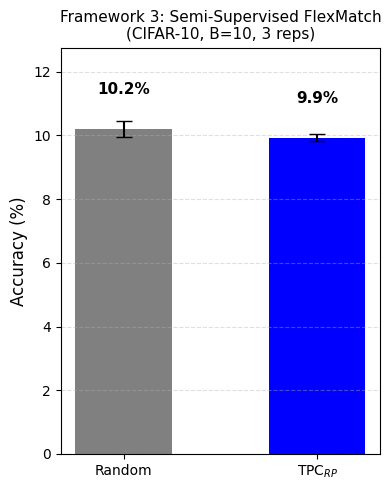

In [24]:
tpcrp_ssl  = np.load('flexmatch_tpcrp_accs.npy')
random_ssl = np.load('flexmatch_random_accs.npy')

tpcrp_mean  = tpcrp_ssl.mean()
tpcrp_std   = tpcrp_ssl.std()
random_mean = random_ssl.mean()
random_std  = random_ssl.std()

fig, ax = plt.subplots(figsize=(4, 5))
bars = ax.bar(['Random', 'TPC$_{RP}$'],
              [random_mean, tpcrp_mean],
              yerr=[random_std, tpcrp_std],
              color=['grey', 'blue'],
              capsize=6, width=0.5)

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Framework 3: Semi-Supervised FlexMatch\n(CIFAR-10, B=10, 3 reps)', fontsize=11)
ax.set_ylim(0, max(tpcrp_mean, random_mean) * 1.25)

for bar, val in zip(bars, [random_mean, tpcrp_mean]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot_framework3.png', dpi=150)
plt.show()

## Statistical Analysis: Verifying t-test values

In [18]:
# Framework 1
tpcrp_f1 = np.load('tpcrp_accuracies.npy')
random_f1 = np.load('random_accuracies.npy')
print("F1 TPCRP std:", tpcrp_f1.std(axis=0).round(2))
print("F1 Random std:", random_f1.std(axis=0).round(2))

# Framework 2
random_f2 = np.load('random_lp_accuracies.npy')
print("F2 Random std:", random_f2.std(axis=0).round(2))
print("F2 Random final-round values:", random_f2[:, -1].round(2))

# Framework 2 one-sample t-test
from scipy.stats import ttest_1samp
t, p = ttest_1samp(random_f2[:, -1], 64.5)
print(f"F2 one-sample t-test: t={t:.2f}, p={p:.6f}")

# Framework 1 Welch's t-test (verify)
from scipy.stats import ttest_ind
t, p = ttest_ind(tpcrp_f1[:, -1], random_f1[:, -1], equal_var=False)
print(f"F1 Welch t-test: t={t:.2f}, p={p:.6f}")

F1 TPCRP std: [0.78 1.12 0.87 1.66 1.34]
F1 Random std: [1.51 1.97 1.64 2.18 1.38]
F2 Random std: [2.98 3.79 4.14 2.71 2.83]
F2 Random final-round values: [62.49 59.02 58.95 53.51 62.3  57.7  58.32 60.3  63.92 61.23]
F2 one-sample t-test: t=-5.01, p=0.000734
F1 Welch t-test: t=8.56, p=0.000000
